In [6]:
def segment_object_from_clicks(image, clicks, device=None):
    """
    Segment an object from an image using SAM2 model with multiple click points.

    Args:
        image: PIL Image or numpy array
        clicks: List of tuples containing (x, y) coordinates
                Example: [(500, 375), (1125, 625)]
        device: Device to run the model on. If None, will use CUDA if available

    Returns:
        masks: Tensor of shape (1, num_masks, H, W) containing the segmentation masks
               ranked by quality score
    """
    from transformers import Sam2Processor, Sam2Model
    import torch
    from PIL import Image

    # Set device
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # Load model and processor
    model = Sam2Model.from_pretrained("facebook/sam2-hiera-large").to(device)
    processor = Sam2Processor.from_pretrained("facebook/sam2-hiera-large")

    # Convert image to PIL if necessary
    if not isinstance(image, Image.Image):
        image = Image.fromarray(image).convert("RGB")

    # Format input points: 4D structure (image_dim, object_dim, point_per_object_dim, coordinates)
    input_points = [[[list(click) for click in clicks]]]

    # Format input labels: all positive clicks (1 for positive, 0 for negative)
    # 3D structure (image_dim, object_dim, point_label)
    input_labels = [[[1] * len(clicks)]]

    # Process inputs
    inputs = processor(
        images=image,
        input_points=input_points,
        input_labels=input_labels,
        return_tensors="pt"
    ).to(device)

    # Generate masks
    with torch.no_grad():
        outputs = model(**inputs)

    # Post-process masks to original image size
    masks = processor.post_process_masks(
        outputs.pred_masks.cpu(),
        inputs["original_sizes"]
    )[0]

    print(f"Generated {masks.shape[1]} masks with shape {masks.shape}")

    return masks

You are using a model of type sam2_video to instantiate a model of type sam2. This is not supported for all configurations of models and can yield errors.


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Generated 3 masks with shape torch.Size([1, 3, 3000, 4000])


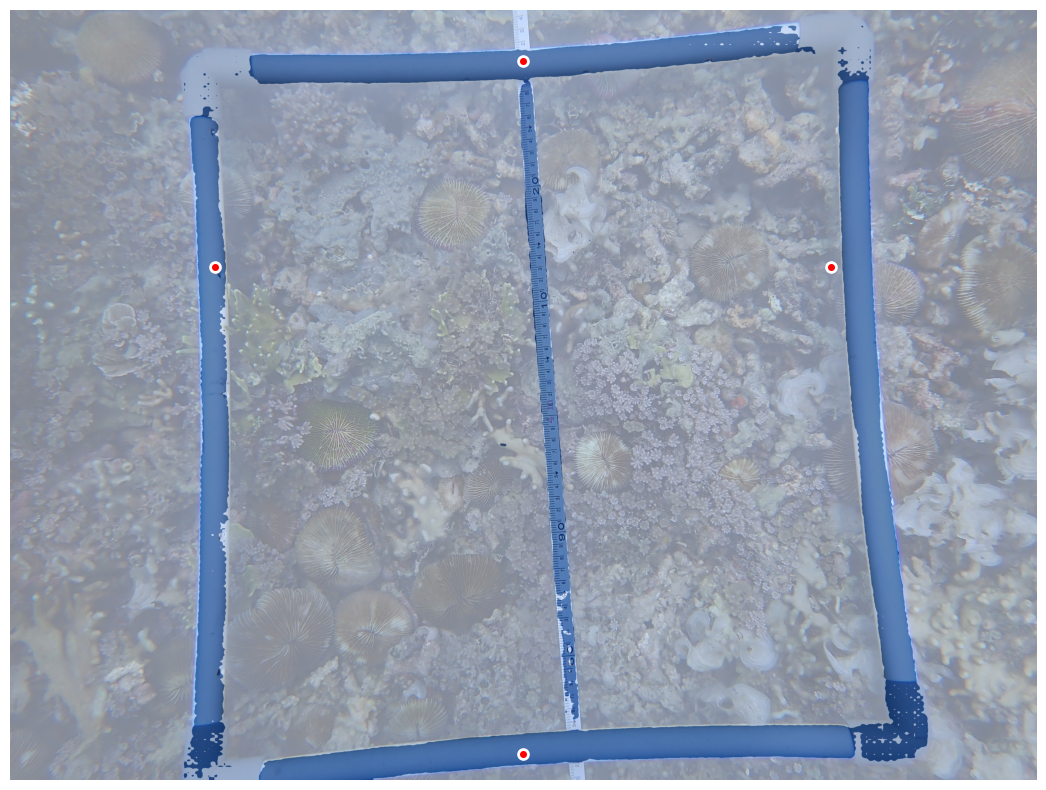

In [23]:
from PIL import Image

# Load your image
image = Image.open("./data_preprocessed/IBF/images/GA 1_PB100638.JPG")

# Define click points (x, y coordinates)
clicks = [(800, 1000), (2000, 2900), (2000, 200),(3200, 1000)]

# Get segmentation masks
masks = segment_object_from_clicks(image, clicks, device="mps")

# The function returns multiple masks ranked by quality
# To get the best mask (highest quality):
best_mask = masks[0, 0]  # First image, first (best) mask

# To visualize the mask with red dots for clicks and blue mask:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Display the image
ax.imshow(image)

# Overlay the best mask in blue
ax.imshow(best_mask, alpha=0.5, cmap='Blues')

# Add red dots for click points
clicks_array = np.array(clicks)
ax.scatter(clicks_array[:, 0], clicks_array[:, 1], c='red', s=50, marker='o', edgecolors='white', linewidths=2)

ax.axis('off')
plt.tight_layout()
plt.show()

tensor([[False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        ...,
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False]])

In [25]:
from PIL import Image
import requests
from transformers import SamHQModel, SamHQProcessor

model = SamHQModel.from_pretrained("syscv-community/sam-hq-vit-large")
processor = SamHQProcessor.from_pretrained("syscv-community/sam-hq-vit-large")

img_url = "https://raw.githubusercontent.com/SysCV/sam-hq/refs/heads/main/demo/input_imgs/example1.png"
raw_image = Image.open(requests.get(img_url, stream=True).raw).convert("RGB")
input_boxes = [[[306, 132, 925, 893]]]  # Bounding box for the image


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.25G [00:00<?, ?B/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/576 [00:00<?, ?B/s]

In [1]:
import torch

mask = torch.load("../data_preprocessed/IBF/masks/GA 1_PB100636_mask.pt")

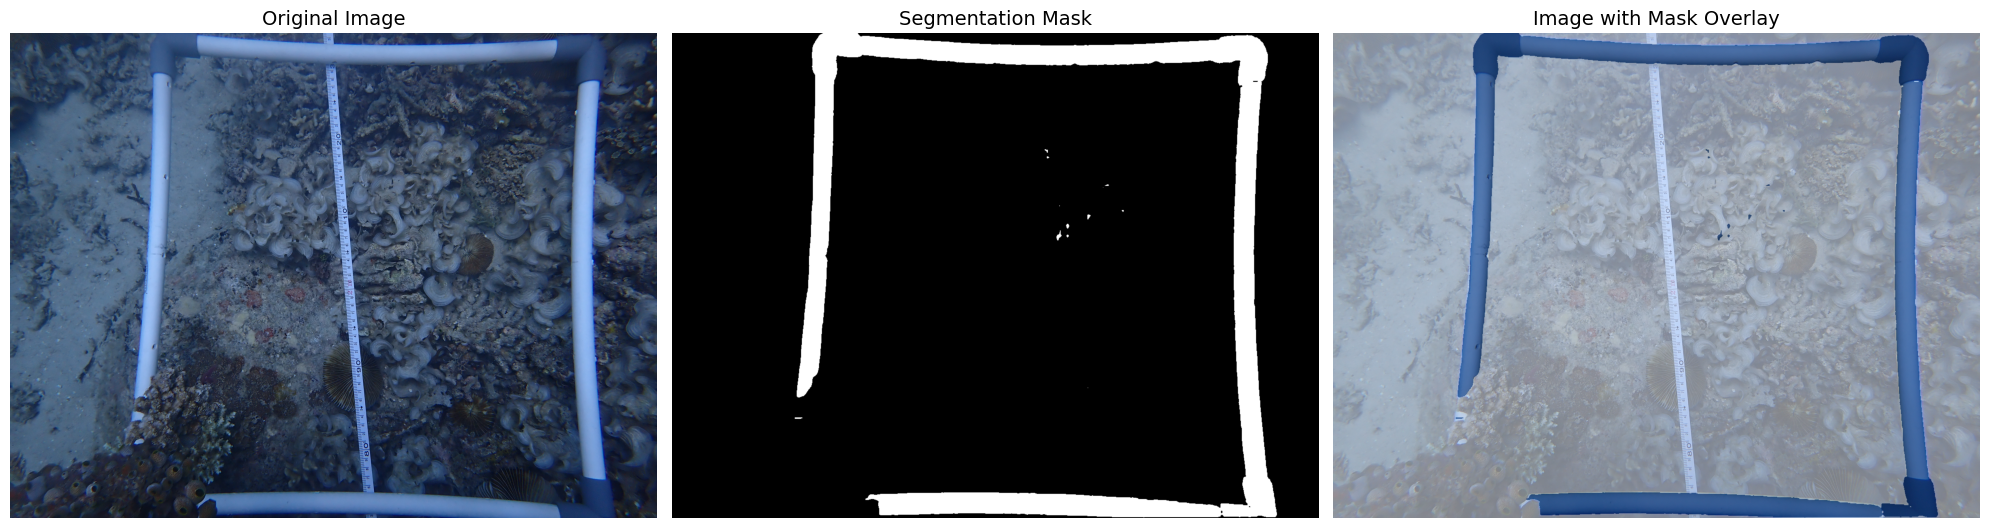

Image: (4000, 3000)
Mask: torch.Size([3000, 4000])
Mask values: tensor([False,  True])


In [3]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Load the mask
mask_path = "../data_preprocessed/IBF/masks/GA 1_PB100636_mask.pt"
mask = torch.load(mask_path)

# Construct the image path from the mask path
mask_filename = Path(mask_path).stem  # Gets "GA 1_PB100636_mask"
image_name = mask_filename.replace("_mask", "")  # Gets "GA 1_PB100636"

# Load the corresponding image
images_dir = Path("../data_preprocessed/IBF/images")
image_path = images_dir / f"{image_name}.JPG"

# Try alternate extension if JPG doesn't exist
if not image_path.exists():
    image_path = images_dir / f"{image_name}.jpg"

if not image_path.exists():
    raise FileNotFoundError(f"Image not found: {image_path}")

# Load the image
image = Image.open(image_path).convert("RGB")

# Convert mask to numpy for visualization
mask_np = mask.cpu().numpy() if torch.is_tensor(mask) else mask

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Original image
axes[0].imshow(image)
axes[0].set_title("Original Image", fontsize=14)
axes[0].axis('off')

# Mask only
axes[1].imshow(mask_np, cmap='gray')
axes[1].set_title("Segmentation Mask", fontsize=14)
axes[1].axis('off')

# Image with mask overlay
axes[2].imshow(image)
axes[2].imshow(mask_np, alpha=0.5, cmap='Blues')
axes[2].set_title("Image with Mask Overlay", fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Image: {image.size}")
print(f"Mask: {mask.shape}")
print(f"Mask values: {mask.unique() if torch.is_tensor(mask) else np.unique(mask)}")